# 성북구 아파트 실거래가 예측 - 머신러닝 모델링

**사용 모델:** 선형 회귀 / 랜덤 포레스트 / 그래디언트 부스팅 / 히스토그램 기반 그래디언트 부스팅

---
## 1. 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from matplotlib import rcParams
rcParams['font.family'] = 'Malgun Gothic'   
rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

np.random.seed(42)

---
## 2. 데이터 로딩 및 기본 확인

In [2]:
df = pd.read_csv('final.csv', low_memory=False)

print('데이터 크기:', df.shape)
print()
print('결측치 현황 :')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('타겟 변수(거래금액_만원) 기본 통계:')
print(df['거래금액_만원'].describe())

데이터 크기: (11087, 71)

결측치 현황 :
도로명_key              2
난방방식                17
지상주차대수               9
지하주차대수               9
CCTV대수               9
홈네트워크               52
단지명_key_manual    9102
세대당_CCTV대수           9
dtype: int64

타겟 변수(거래금액_만원) 기본 통계:
count     11087.000000
mean      81930.785515
std       23043.572146
min        9800.000000
25%       67900.000000
50%       80000.000000
75%       95000.000000
max      210000.000000
Name: 거래금액_만원, dtype: float64


---
## 3. 변수 선택

### 선택 근거

| 변수 | 유형 | 선택 근거 |
|------|------|-----------|
| 전용면적 | 물리적 특성 | 면적이 클수록 가격 상승 — 가장 직접적인 가격 결정 요인 |
| 건물나이 | 물리적 특성 | 노후화된 건물일수록 시세 하락 경향 |
| 층 | 물리적 특성 | 고층일수록 조망·채광 등으로 프리미엄 부여 |
| 최고층수 | 물리적 특성 | 단지 최고 층수 → 고층 단지일수록 조망·희소성 프리미엄 반영 |
| 기준금리 | 거시경제 | 금리 상승 시 대출 부담 증가 → 수요 감소 → 가격 하락 |
| 역세권여부 | 입지 | 지하철 접근성 → 통근 편의 → 수요 증가 |
| 반경500m_병원수 | 생활 인프라 | 의료 접근성 → 주거 편의 지표 |
| 반경500m_공원수 | 생활 인프라 | 자연환경 접근성 → 삶의 질 지표 |
| 반경500m_소상공인수 | 생활 인프라 | 상업 편의시설 밀도 → 생활 편의 지표 (Step 4 생성 변수) |
| 반경500m_버스정류장 | 교통 인프라 | 버스 접근성 → 대중교통 편의 → 수요 증가 |
| 브랜드선호도_TOP20 | 브랜드 | 대형 건설사 브랜드 → 품질·관리·인지도 프리미엄 |
| 세대당_주차대수 | 단지 특성 | 주차 편의성 → 단지 품질 지표 |
| 복도유형 | 단지 특성 | 계단식·복도식·혼합식 → 단지 구조 및 프라이버시 수준 반영 |
| 단지내_편의시설_유무 | 단지 특성 | 단지 내 편의시설 존재 여부 → 생활 편의 및 단지 품질 지표 |
| 500m내_편의시설_총합 | 복합 지표 | 생활 편의시설 종합 접근성 (병원+공원+소상공인 통합) |
| 경사도 | 지형 | 경사가 급할수록 이동 불편 → 거주 선호도 하락 |
| 고도 | 지형 | 고도가 높을수록 접근성 불편 → 거주 선호도 하락 |

### 제외 변수
- **동별_총인구 / 세대당_인구**: 성북구 단일 자치구 내 데이터로 동 간 인구 편차가 아파트 시세에 미치는 영향이 제한적이며, 특성 중요도 분석에서도 하위권으로 확인되어 제외
- **반경500m_학교수 / 년도 / 월**: 팀 공통 변수 목록에서 제외


In [3]:
# 복도유형 숫자 변환 (계단식=0, 복도식=1, 혼합식=2)
df['복도유형_코드'] = df['복도유형'].map({'계단식': 0, '복도식': 1, '혼합식': 2})

# 사용할 입력 변수 목록 (17개)
feature_cols = [
    # 물리적 특성
    '전용면적', '건물나이', '층', '최고층수',
    # 거시경제
    '기준금리',
    # 입지 / 생활 인프라
    '역세권여부', '반경500m_병원수',
    '반경500m_공원수', '반경500m_소상공인수',
    '반경500m_버스정류장',
    # 단지 특성
    '브랜드선호도_TOP20', '세대당_주차대수',
    '복도유형_코드', '단지내_편의시설_유무',
    # 복합 지표
    '500m내_편의시설_총합',
    # 지형
    '경사도', '고도',
]

target_col = '거래금액_만원'

data = df[feature_cols + ['년도', target_col]].copy()

print('분석 데이터 크기:', data.shape)
print('결측치:', data.isnull().sum().sum())


분석 데이터 크기: (11087, 19)
결측치: 0


---
## 4. 데이터 전처리 및 분할

In [4]:
# 시간 기반 분할 (2021~2024년 훈련 / 2025년 테스트)
# 과거 거래 데이터로 학습 후 2025년 실거래가 예측
train_data = data[data['년도'] < 2025]
test_data = data[data['년도'] == 2025]

train_input = train_data[feature_cols].values
test_input = test_data[feature_cols].values
train_target = train_data[target_col].values
test_target = test_data[target_col].values

print('훈련 세트 크기 (2021~2024):', train_input.shape)
print('테스트 세트 크기 (2025):', test_input.shape)


훈련 세트 크기 (2021~2024): (6995, 17)
테스트 세트 크기 (2025): (4092, 17)


In [5]:
# 표준화(선형 회귀에만 적용)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_input)
test_scaled = scaler.transform(test_input)

print('표준화 완료')
print('훈련 세트 평균(첫 5개 특성):', train_scaled[:, :5].mean(axis=0).round(4))
print('훈련 세트 표준편차(첫 5개 특성):', train_scaled[:, :5].std(axis=0).round(4))

표준화 완료
훈련 세트 평균(첫 5개 특성): [ 0. -0.  0.  0.  0.]
훈련 세트 표준편차(첫 5개 특성): [1. 1. 1. 1. 1.]


---
## 5. 모델 학습 및 평가

### 평가 지표
- **R²** (결정계수): 1에 가까울수록 좋음
- **MAE** (평균 절대 오차): 실제 단위(만원)로 직관적 해석 가능
- **RMSE** (제곱근 평균 제곱 오차): 큰 오차에 더 민감하게 반응

In [6]:
# 평가 함수 정의
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test,  y_test)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print(f'[{name}]')
    print(f'훈련 세트 R² : {train_r2:.4f}')
    print(f'테스트 세트 R² : {test_r2:.4f}')
    print(f'MAE : {mae:,.0f} 만원')
    print(f'RMSE : {rmse:,.0f} 만원')
    print()

    return {'모델': name, '훈련R²': train_r2, '테스트R²': test_r2,
            'MAE': mae, 'RMSE': rmse, '예측값': pred}

### 5-1. 선형 회귀 (Linear Regression)

In [7]:
lr = LinearRegression()
lr.fit(train_scaled, train_target)

print('[선형 회귀]')
print('훈련 세트 R² :', round(lr.score(train_scaled, train_target), 4))
print('테스트 세트 R² :', round(lr.score(test_scaled, test_target), 4))

pred_lr = lr.predict(test_scaled)
mae_lr = mean_absolute_error(test_target, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(test_target, pred_lr))
print('MAE :', round(mae_lr, 0), '만원')
print('RMSE:', round(rmse_lr, 0), '만원')

[선형 회귀]
훈련 세트 R² : 0.7874
테스트 세트 R² : 0.7001
MAE : 9781.0 만원
RMSE: 12951.0 만원


### 5-2. 랜덤 포레스트 (Random Forest)

In [8]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(train_input, train_target)

print('[랜덤 포레스트]')
print('훈련 세트 R² :', round(rf.score(train_input, train_target), 4))
print('테스트 세트 R² :', round(rf.score(test_input, test_target), 4))

pred_rf = rf.predict(test_input)
mae_rf = mean_absolute_error(test_target, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(test_target, pred_rf))
print('MAE :', round(mae_rf, 0), '만원')
print('RMSE :', round(rmse_rf, 0), '만원')

[랜덤 포레스트]
훈련 세트 R² : 0.9875
테스트 세트 R² : 0.7867
MAE : 7722.0 만원
RMSE : 10922.0 만원


### 5-3. 그래디언트 부스팅 (Gradient Boosting)

In [9]:
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb.fit(train_input, train_target)

print('[그래디언트 부스팅]')
print('훈련 세트 R² :', round(gb.score(train_input, train_target), 4))
print('테스트 세트 R² :', round(gb.score(test_input, test_target), 4))

pred_gb = gb.predict(test_input)
mae_gb = mean_absolute_error(test_target, pred_gb)
rmse_gb = np.sqrt(mean_squared_error(test_target, pred_gb))
print('MAE :', round(mae_gb, 0), '만원')
print('RMSE :', round(rmse_gb, 0), '만원')

[그래디언트 부스팅]
훈련 세트 R² : 0.9352
테스트 세트 R² : 0.808
MAE : 7598.0 만원
RMSE : 10364.0 만원


### 5-4. 히스토그램 기반 그래디언트 부스팅 (HistGradientBoosting)

In [10]:
hgb = HistGradientBoostingRegressor(max_iter=200, random_state=42)
hgb.fit(train_input, train_target)

print('[히스토그램 기반 그래디언트 부스팅]')
print('훈련 세트 R² :', round(hgb.score(train_input, train_target), 4))
print('테스트 세트 R² :', round(hgb.score(test_input, test_target), 4))

pred_hgb = hgb.predict(test_input)
mae_hgb = mean_absolute_error(test_target, pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(test_target, pred_hgb))
print('MAE :', round(mae_hgb, 0), '만원')
print('RMSE:', round(rmse_hgb, 0), '만원')

[히스토그램 기반 그래디언트 부스팅]
훈련 세트 R² : 0.9662
테스트 세트 R² : 0.8315
MAE : 7076.0 만원
RMSE: 9707.0 만원


---
## 6. 모델 성능 비교

In [11]:
# 모델별 R² 비교 데이터
model_names  = ['선형 회귀', '랜덤 포레스트', '그래디언트 부스팅', '히스토그램 기반 GB']
train_scores = [lr.score(train_scaled, train_target), rf.score(train_input, train_target),
                gb.score(train_input, train_target),  hgb.score(train_input, train_target)]
test_scores  = [lr.score(test_scaled,  test_target),  rf.score(test_input,  test_target),
                gb.score(test_input,   test_target),  hgb.score(test_input,  test_target)]

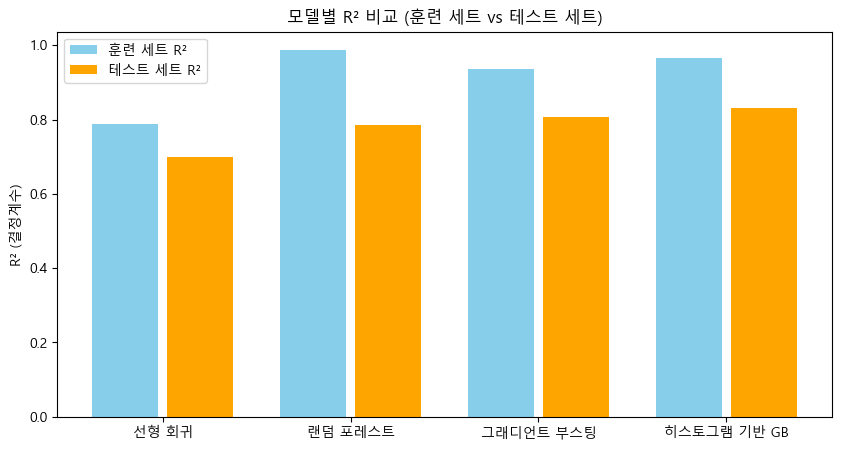

In [12]:
# R² 비교 그래프
x = np.arange(4)
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, train_scores, width=0.35, label='훈련 세트 R²', color='skyblue')
plt.bar(x + 0.2, test_scores, width=0.35, label='테스트 세트 R²', color='orange')
plt.xticks(x, model_names)
plt.ylabel('R² (결정계수)')
plt.title('모델별 R² 비교 (훈련 세트 vs 테스트 세트)')
plt.legend()
plt.show()

In [13]:
# MAE / RMSE 비교 데이터
mae_vals   = [mae_lr,  mae_rf,  mae_gb,  mae_hgb]
rmse_vals  = [rmse_lr, rmse_rf, rmse_gb, rmse_hgb]
bar_labels = ['선형 회귀', '랜덤 포레스트', '그래디언트 부스팅', '히스토그램 기반 GB']

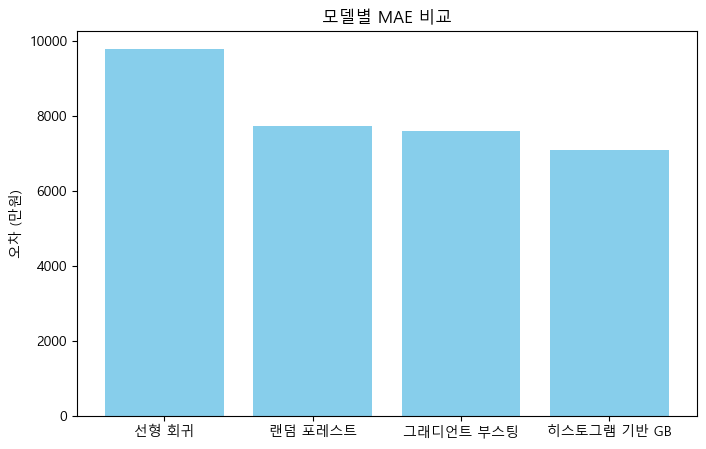

In [14]:
# MAE 비교 그래프
plt.figure(figsize=(8, 5))
plt.bar(bar_labels, mae_vals, color='skyblue')
plt.title('모델별 MAE 비교')
plt.ylabel('오차 (만원)')
plt.show()

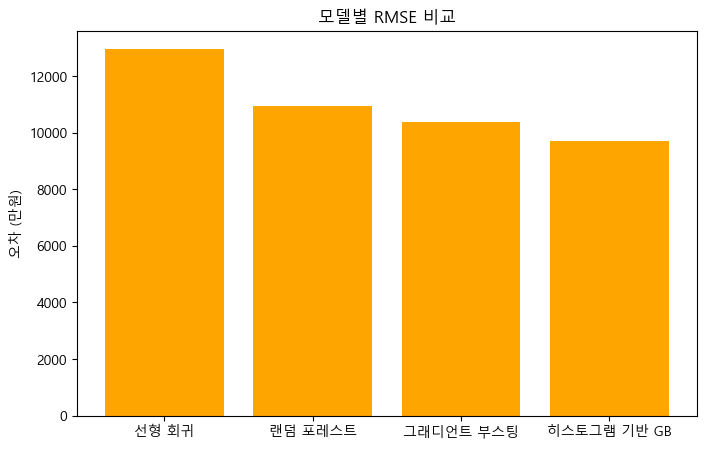

In [15]:
# RMSE 비교 그래프
plt.figure(figsize=(8, 5))
plt.bar(bar_labels, rmse_vals, color='orange')
plt.title('모델별 RMSE 비교')
plt.ylabel('오차 (만원)')
plt.show()

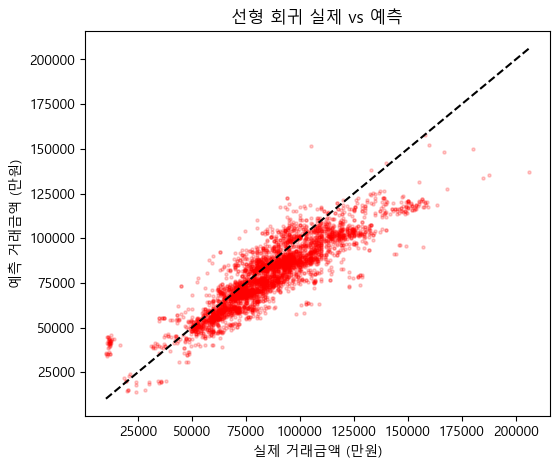

In [16]:
# 선형 회귀
plt.figure(figsize=(6, 5))
plt.scatter(test_target, pred_lr, alpha=0.2, s=5, color='red')
plt.plot([test_target.min(), test_target.max()],
         [test_target.min(), test_target.max()], 
         linestyle='dashed', color='k')
plt.title('선형 회귀 실제 vs 예측')
plt.xlabel('실제 거래금액 (만원)')
plt.ylabel('예측 거래금액 (만원)')
plt.show()



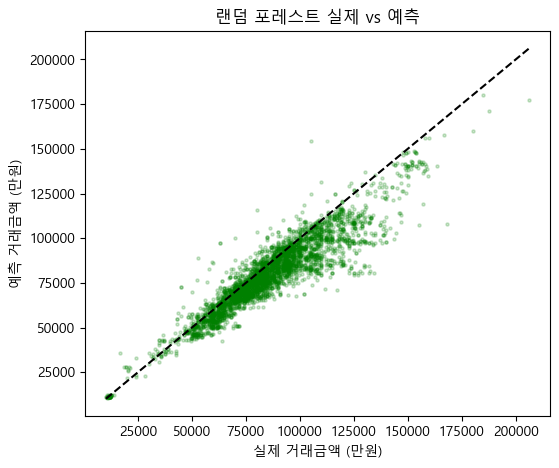

In [17]:
# 랜덤 포레스트
plt.figure(figsize=(6, 5))
plt.scatter(test_target, pred_rf, alpha=0.2, s=5, color='green')
plt.plot([test_target.min(), test_target.max()],
         [test_target.min(), test_target.max()],
         linestyle='dashed', color='k')
plt.title('랜덤 포레스트 실제 vs 예측')
plt.xlabel('실제 거래금액 (만원)')
plt.ylabel('예측 거래금액 (만원)')
plt.show()

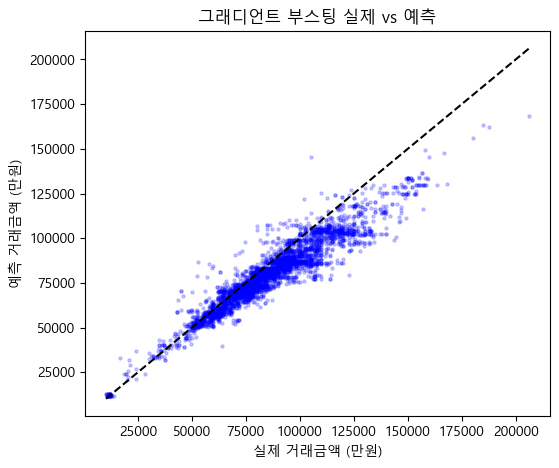

In [18]:
# 그래디언트 부스팅
plt.figure(figsize=(6, 5))
plt.scatter(test_target, pred_gb, alpha=0.2, s=5, color='blue')
plt.plot([test_target.min(), test_target.max()],
         [test_target.min(), test_target.max()],
         linestyle='dashed', color='k')
plt.title('그래디언트 부스팅 실제 vs 예측')
plt.xlabel('실제 거래금액 (만원)')
plt.ylabel('예측 거래금액 (만원)')
plt.show()

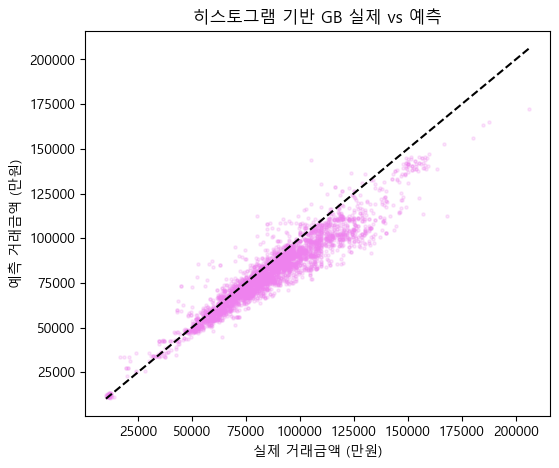

In [19]:
# 히스토그램 기반 GB
plt.figure(figsize=(6, 5))
plt.scatter(test_target, pred_hgb, alpha=0.2, s=5, color='violet')
plt.plot([test_target.min(), test_target.max()],
         [test_target.min(), test_target.max()],
         linestyle='dashed', color='k')
plt.title('히스토그램 기반 GB 실제 vs 예측')
plt.xlabel('실제 거래금액 (만원)')
plt.ylabel('예측 거래금액 (만원)')
plt.show()

---
## 7. 교차 검증 (Cross Validation)

- 단일 train_test_split은 특정 분할 방식에 따라 결과가 달라질 수 있음
- **5-폴드 교차 검증**으로 훈련 세트를 5등분하여 4개로 학습, 1개로 검증을 5회 반복
- `return_train_score=True` 로 훈련 점수도 함께 반환하여 과대적합 여부 판단
- 회귀 문제이므로 수업 내용에 따라 `KFold` 사용

In [20]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 선형 회귀
scores_lr = cross_validate(lr, train_scaled, train_target, cv=kfold, return_train_score=True, n_jobs=-1)
print('[선형 회귀]')
print('훈련 평균 R² :', round(np.mean(scores_lr['train_score']), 4))
print('검증 평균 R² :', round(np.mean(scores_lr['test_score']), 4))
print('검증 표준편차 :', round(np.std(scores_lr['test_score']), 4))
print()

# 랜덤 포레스트
scores_rf = cross_validate(rf, train_input, train_target, cv=kfold, return_train_score=True, n_jobs=-1)
print('[랜덤 포레스트]')
print('훈련 평균 R² :', round(np.mean(scores_rf['train_score']), 4))
print('검증 평균 R² :', round(np.mean(scores_rf['test_score']), 4))
print('검증 표준편차 :', round(np.std(scores_rf['test_score']), 4))
print()

# 그래디언트 부스팅
scores_gb = cross_validate(gb, train_input, train_target, cv=kfold, return_train_score=True, n_jobs=-1)
print('[그래디언트 부스팅]')
print('훈련 평균 R² :', round(np.mean(scores_gb['train_score']), 4))
print('검증 평균 R² :', round(np.mean(scores_gb['test_score']), 4))
print('검증 표준편차 :', round(np.std(scores_gb['test_score']), 4))
print()

# 히스토그램 기반 GB
scores_hgb = cross_validate(hgb, train_input, train_target, cv=kfold, return_train_score=True, n_jobs=-1)
print('[히스토그램 기반 그래디언트 부스팅]')
print('훈련 평균 R² :', round(np.mean(scores_hgb['train_score']), 4))
print('검증 평균 R² :', round(np.mean(scores_hgb['test_score']), 4))
print('검증 표준편차 :', round(np.std(scores_hgb['test_score']), 4))

[선형 회귀]
훈련 평균 R² : 0.7875
검증 평균 R² : 0.7864
검증 표준편차 : 0.0149

[랜덤 포레스트]
훈련 평균 R² : 0.9876
검증 평균 R² : 0.9293
검증 표준편차 : 0.0068

[그래디언트 부스팅]
훈련 평균 R² : 0.9367
검증 평균 R² : 0.9235
검증 표준편차 : 0.0081

[히스토그램 기반 그래디언트 부스팅]
훈련 평균 R² : 0.9676
검증 평균 R² : 0.9377
검증 표준편차 : 0.0069


---
## 8. 결과 해석 및 분석

### 8-1. 모델 성능 요약
- 훈련: 2021~2024년 실거래 데이터 / 테스트: 2025년 실거래 데이터

| 모델 | 훈련 R² | 테스트 R² | MAE | RMSE | 특징 |
|------|--------|---------|-----|------|------|
| 선형 회귀 | 0.7874 | 0.7001 | 9,781만원 | 12,951만원 | 변수 간 선형 관계만 포착, 계수로 해석 용이 |
| 랜덤 포레스트 | 0.9875 | 0.7867 | 7,722만원 | 10,922만원 | 과대적합 억제력 강함, 안정적 |
| 그래디언트 부스팅 | 0.9352 | 0.8080 | 7,598만원 | 10,364만원 | 순차 학습으로 오차 집중 교정 |
| 히스토그램 기반 GB | 0.9662 | 0.8315 | 7,076만원 | 9,707만원 | 빠른 학습, 결측치 자체 처리, 최고 성능 |

### 8-2. 교차 검증 결과 (5-폴드)

| 모델 | 훈련 R² (평균) | 검증 R² (평균) | 표준편차 |
|------|-------------|-------------|---------|
| 선형 회귀 | 0.7875 | 0.7864 | 0.0149 |
| 랜덤 포레스트 | 0.9876 | 0.9293 | 0.0068 |
| 그래디언트 부스팅 | 0.9367 | 0.9235 | 0.0081 |
| 히스토그램 기반 GB | 0.9676 | 0.9377 | 0.0069 |

### 8-3. 주요 발견

1. **전용면적**이 전 모델에서 가장 중요한 변수로 확인
   → 아파트 가격 결정의 가장 핵심적인 물리적 속성임을 재확인

2. **기준금리**가 예상보다 높은 중요도
   → 2021~2025년 분석 기간은 금리 급변동기(0.5% → 3.5% → 인하)였으므로 금리 변화가 실거래가에 실질적으로 반영됨

3. **건물나이**의 역방향 효과 확인
   → 노후화가 가격 하락에 기여

4. **역세권 여부**가 의미 있는 프리미엄을 형성
   → 역세권 평균(85,600만원) vs 비역세권 평균(79,780만원) → 약 5,820만원 차이

5. **시간 기반 분할 적용**
   → 2021~2024년 데이터로 학습 후 2025년 실거래가 예측
   → 랜덤 분할 대비 테스트 R² 감소 → 미래 데이터 누수 없는 정직한 성능 평가

6. **고층여부 → 최고층수 변경 효과**
   → 전 모델에서 테스트 R² 상승 → 최고층수가 단지 규모와 희소성을 더 잘 반영함을 확인

7. **선형 회귀 한계**
   → 앙상블 모델 대비 R²가 낮음
   → 아파트 가격에는 변수 간 비선형 상호작용이 존재하기 때문

8. **히스토그램 기반 GB**
   → 테스트 R² 최고(0.8315) + MAE 최소(7,076만원) → 성능과 안정성 모두 우수